Most Similar pair : Serotonin & Melatonin
Similarity score : 0.388


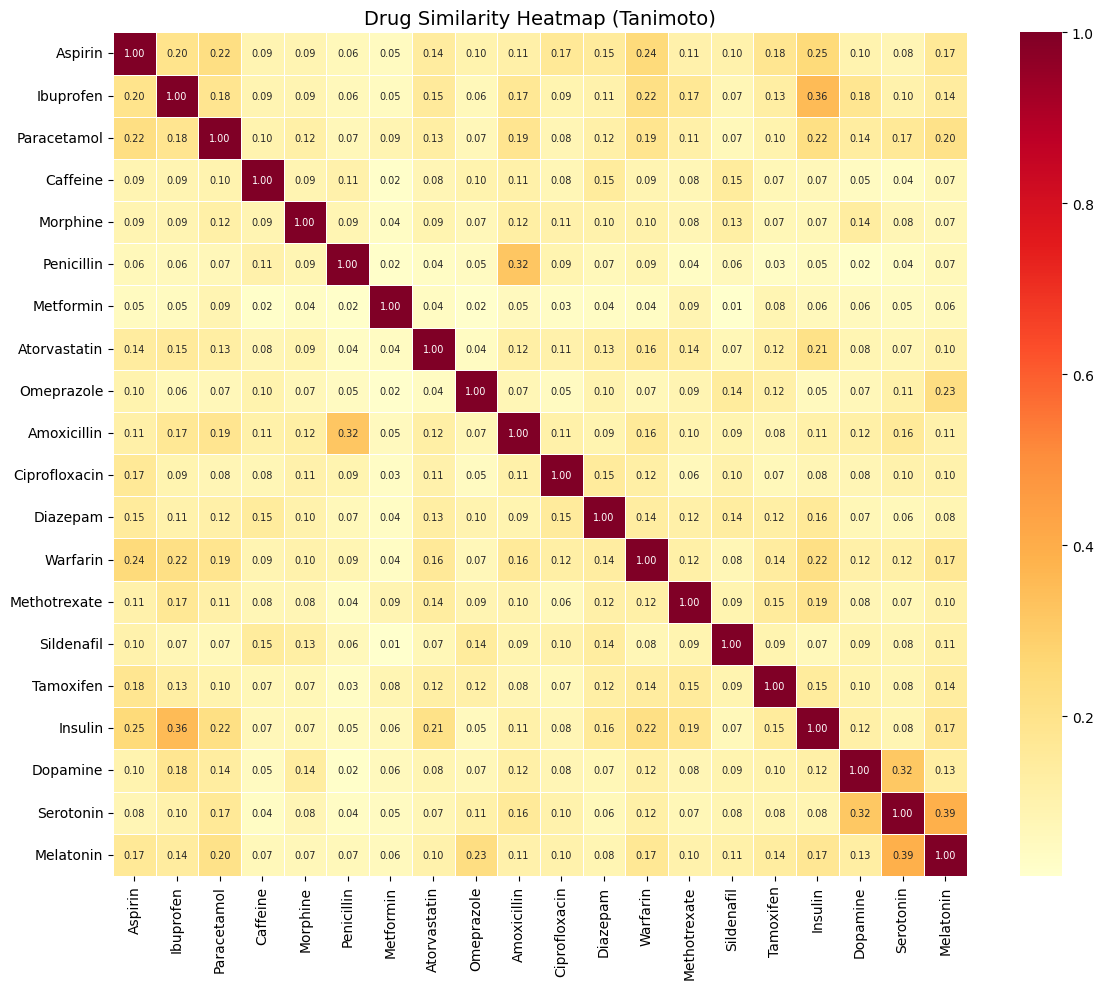

In [3]:
!pip install rdkit
!pip install seaborn

from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit import  DataStructs
import matplotlib.pyplot as plt
from rdkit.Chem import rdFingerprintGenerator
import pandas as pd
import numpy as np
import seaborn as sns

drugs = {
    "Aspirin":     "CC(=O)Oc1ccccc1C(=O)O",
    "Ibuprofen":   "CC(C)Cc1ccc(cc1)C(C)C(=O)O",
    "Paracetamol": "CC(=O)Nc1ccc(O)cc1",
    "Caffeine":    "Cn1cnc2c1c(=O)n(c(=O)n2C)C",
    "Morphine":    "OC1=CC=C2CC3N(C)CCC34C2=C1OC4",
    "Penicillin":  "CC1(C)SC2C(NC1=O)C(=O)O2",
    "Metformin":   "CN(C)C(=N)NC(=N)N",
    "Atorvastatin":"CC(C)c1n(CC(O)CC(O)CC(=O)O)c(-c2ccccc2)c(C(=O)Nc2ccccc2F)c1CC",
    "Omeprazole":  "COc1ccc2[nH]c(SC3=NC=C(OC)C(C)=C3C)nc2c1",
    "Amoxicillin": "CC1(C)SC2C(NC1=O)C(=O)N2CC(N)c1ccc(O)cc1",
    "Ciprofloxacin":"O=C(O)c1cn(C2CC2)c2cc(N3CCNCC3)c(F)cc2c1=O",
    "Diazepam":    "CN1C(=O)CN=C(c2ccccc2)c2cc(Cl)ccc21",
    "Warfarin":    "CC(=O)CC(c1ccccc1)c1c(O)c2ccccc2oc1=O",
    "Methotrexate":"CN(Cc1cnc2nc(N)nc(N)c2n1)c1ccc(C(=O)NC(CCC(=O)O)C(=O)O)cc1",
    "Sildenafil":  "CCCC1=NN(C)C(=O)c2[nH]c(-c3cc(S(=O)(=O)N4CCN(C)CC4)ccc3OCC)nc21",
    "Tamoxifen":   "CCC(=C(c1ccccc1)c1ccc(OCCN(C)C)cc1)c1ccccc1",
    "Insulin":     "CC(C)CC(NC(=O)C(Cc1ccccc1)NC(=O)C)C(=O)O",
    "Dopamine":    "NCCc1ccc(O)c(O)c1",
    "Serotonin":   "NCCc1c[nH]c2ccc(O)cc12",
    "Melatonin":   "COc1ccc2[nH]cc(CCNC(C)=O)c2c1"
}

names = list(drugs.keys())

mols = [Chem.MolFromSmiles(smiles) for smiles in drugs.values()]

gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)
fps = [gen.GetFingerprint(m) for m in mols]

n = len(drugs)
matrix = np.zeros((n, n))

for i in range(n):
  for j in range(n):
    matrix[i, j] = DataStructs.TanimotoSimilarity(fps[i], fps[j])

df = pd.DataFrame(matrix, index=names, columns=names)


np.fill_diagonal(matrix, 0)

idx = np.unravel_index(matrix.argmax(), matrix.shape)

print(f"Most Similar pair : {names[idx[0]]} & {names[idx[1]]}")
print(f"Similarity score : {matrix[idx]:.3f}")


np.fill_diagonal(matrix, 1)
plt.figure(figsize=(12, 10))

sns.heatmap(
    df,
    annot=True,
    fmt=".2f",
    cmap="YlOrRd",
    linewidths=0.5,
    annot_kws={"size": 7}
)

plt.title("Drug Similarity Heatmap (Tanimoto)", fontsize=14)
plt.tight_layout()
plt.show()
